In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

figsize = (15 , 6)
city = 'Delhi'

np.random.seed(56)
print('Done!')

Done!


In [2]:
data = pd.read_csv('aqi.csv')
data = data.drop(columns=['area' , 'number_of_monitoring_stations' , 'unit' , 'note'])
data.head(3)

,date,state,prominent_pollutants,aqi_value,air_quality_status
0,30-04-2025,Maharashtra,PM10,78,Satisfactory
1,30-04-2025,Bihar,CO,56,Satisfactory
2,30-04-2025,Madhya Pradesh,O3,98,Satisfactory


In [3]:
data.shape

(235785, 5)

In [4]:
data.isna().sum().sum()

np.int64(0)

In [5]:
data.drop_duplicates(keep='last' , inplace= True)

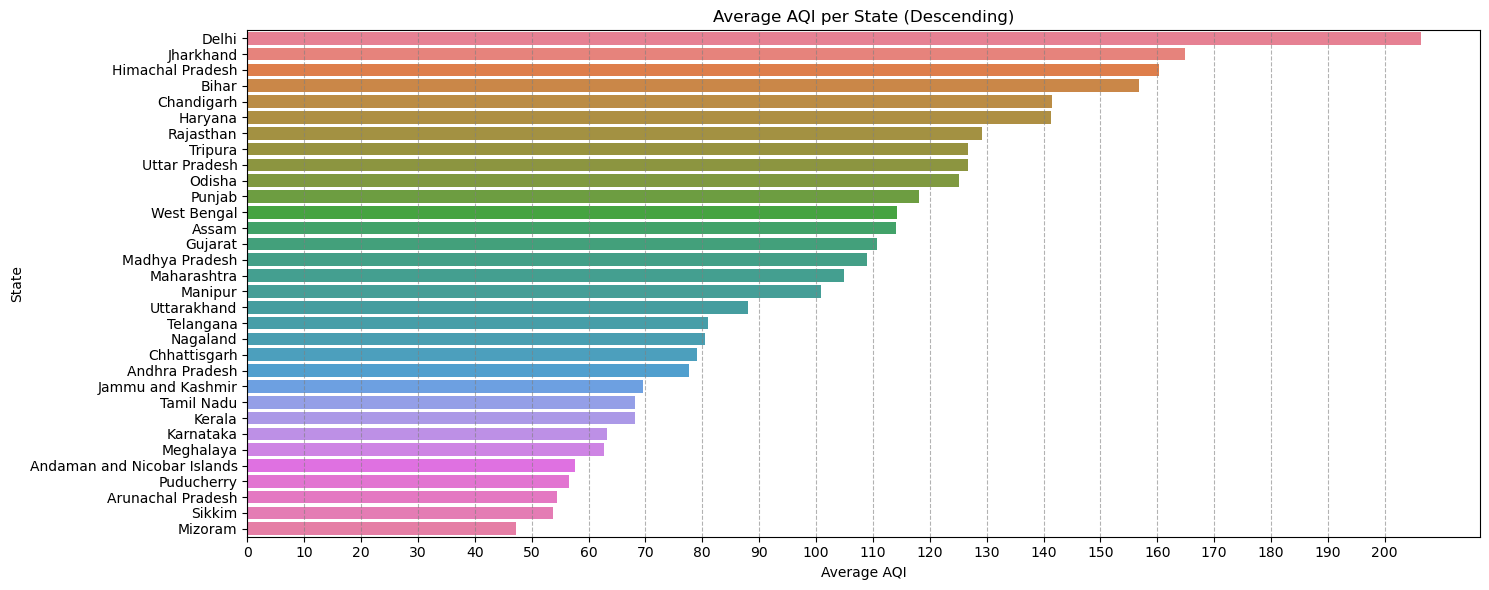

In [6]:
state_aqi = (
    data.groupby('state')['aqi_value']
    .mean()
    .sort_values(ascending=False)   # descending
    .reset_index()
)

fig, ax = plt.subplots(figsize=figsize)

sns.barplot(
    
    data=state_aqi,
    y='state',         
    x='aqi_value',
    hue='state',
    legend=False,
    ax=ax
)

ax.set_title('Average AQI per State (Descending)')
ax.set_xlabel('Average AQI')
ax.set_ylabel('State')
ax.set_xticks([x for x in range(0 , 201 , 10)])
ax.grid(axis='x' , linestyle='--' , color = 'gray' ,  alpha = 0.6)

plt.tight_layout()
plt.show()

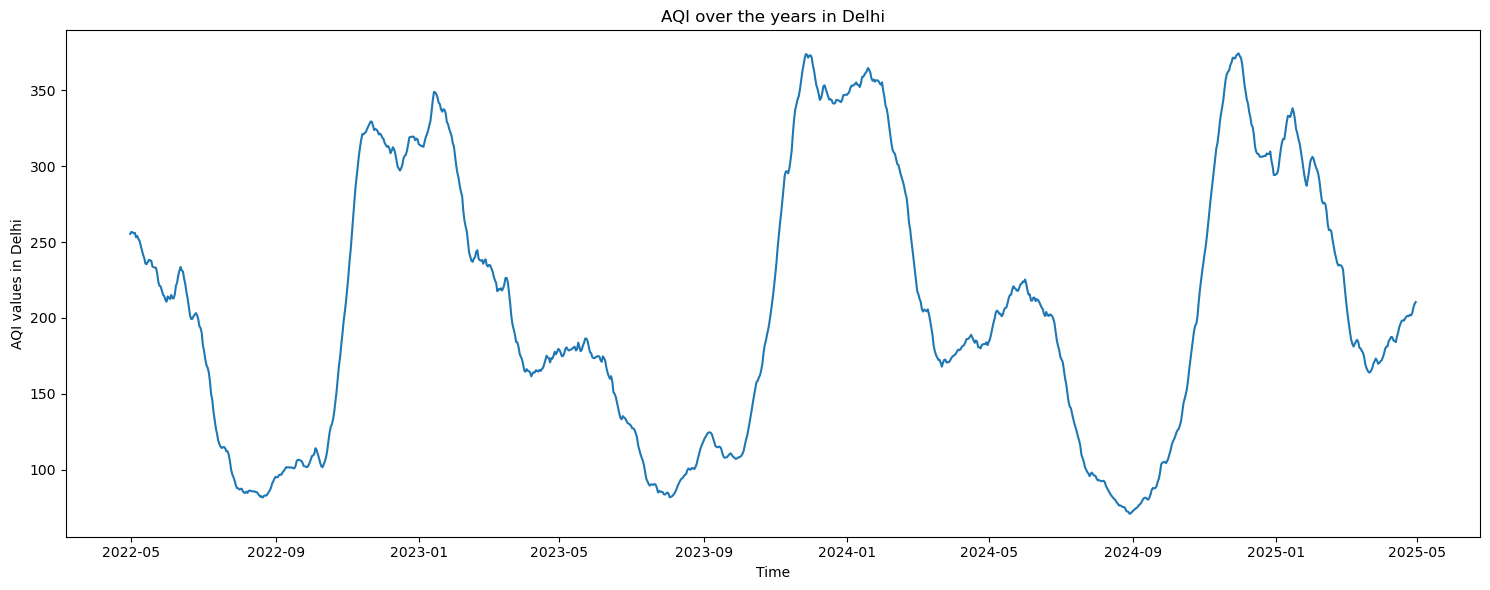

In [7]:
df = data[data['state'] == city].copy()

df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

df = df.groupby('date')['aqi_value'].mean().sort_index()

rolling_mean = df.rolling(window = 30).mean()

plt.figure(figsize=figsize)
plt.plot(rolling_mean)
plt.xlabel('Time')
plt.ylabel('AQI values in Delhi')
plt.title('AQI over the years in Delhi')

plt.tight_layout()
plt.show()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

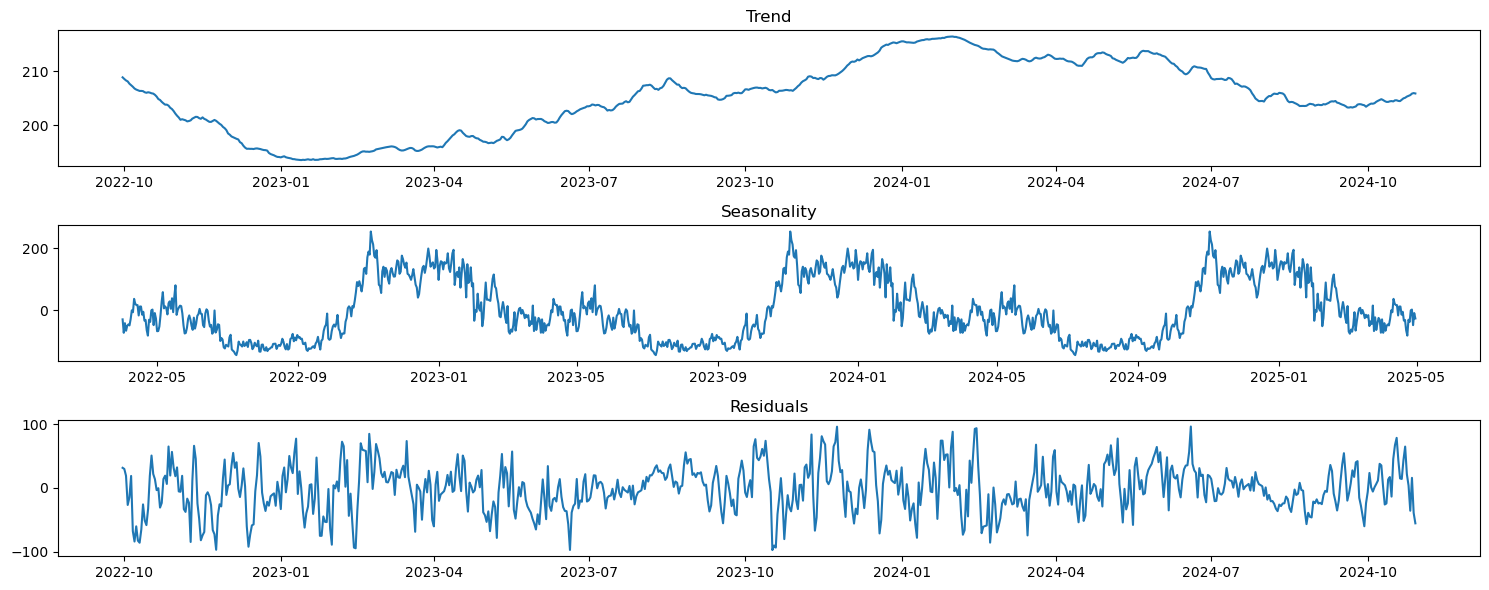

In [9]:
decomposition = seasonal_decompose(df, period=365)

trend = decomposition.trend
seasonal = decomposition.seasonal
resid = decomposition.resid

plt.figure(figsize=figsize)

plt.subplot(3, 1, 1)
plt.plot(trend)
plt.title('Trend')

plt.subplot(3, 1, 2)
plt.plot(seasonal)
plt.title('Seasonality')

plt.subplot(3, 1, 3)
plt.plot(resid)
plt.title('Residuals')

plt.tight_layout()
plt.show()

## Stationarity

In [10]:
from statsmodels.tsa.stattools import adfuller

In [11]:
def test_stationary(timeseries):

    roll_mean = timeseries.rolling(window=30).mean()
    roll_std = timeseries.rolling(window=30).std()

    fig , axs = plt.subplots(2,1 , figsize = figsize)
    axs = axs.flatten()
    
    axs[0].plot(roll_mean , color = 'red' , label = 'rolling mean')
    axs[0].plot(timeseries , color = 'blue' , label = 'original data')
    axs[0].legend(loc = 'best')
    axs[0].set_title('rolling mean')
    
    axs[1].plot(roll_std , color = 'red' , label = 'rolling std' )
    axs[1].plot(timeseries , color = 'blue' , label = 'original data')
    axs[1].set_title('rolling standard deviation')
    axs[1].legend(loc = 'best')
    
    plt.tight_layout()

    dftest = adfuller(timeseries , autolag='AIC')
    df_output = pd.DataFrame(dftest[0:4] , index=['test stat'  , 'p values' , '#lags' , '#observations'])
    for key , val in dftest[4].items():
        df_output[f'Critaical value {key}%'] = val

    print(df_output)

### Log-transforming the data

In [12]:
log_scaled = np.log(df)

                         0  Critaical value 1%%  Critaical value 5%%  \
test stat        -2.724952             -3.43625            -2.864145   
p values          0.069819             -3.43625            -2.864145   
#lags            13.000000             -3.43625            -2.864145   
#observations  1111.000000             -3.43625            -2.864145   

               Critaical value 10%%  
test stat                 -2.568157  
p values                  -2.568157  
#lags                     -2.568157  
#observations             -2.568157  


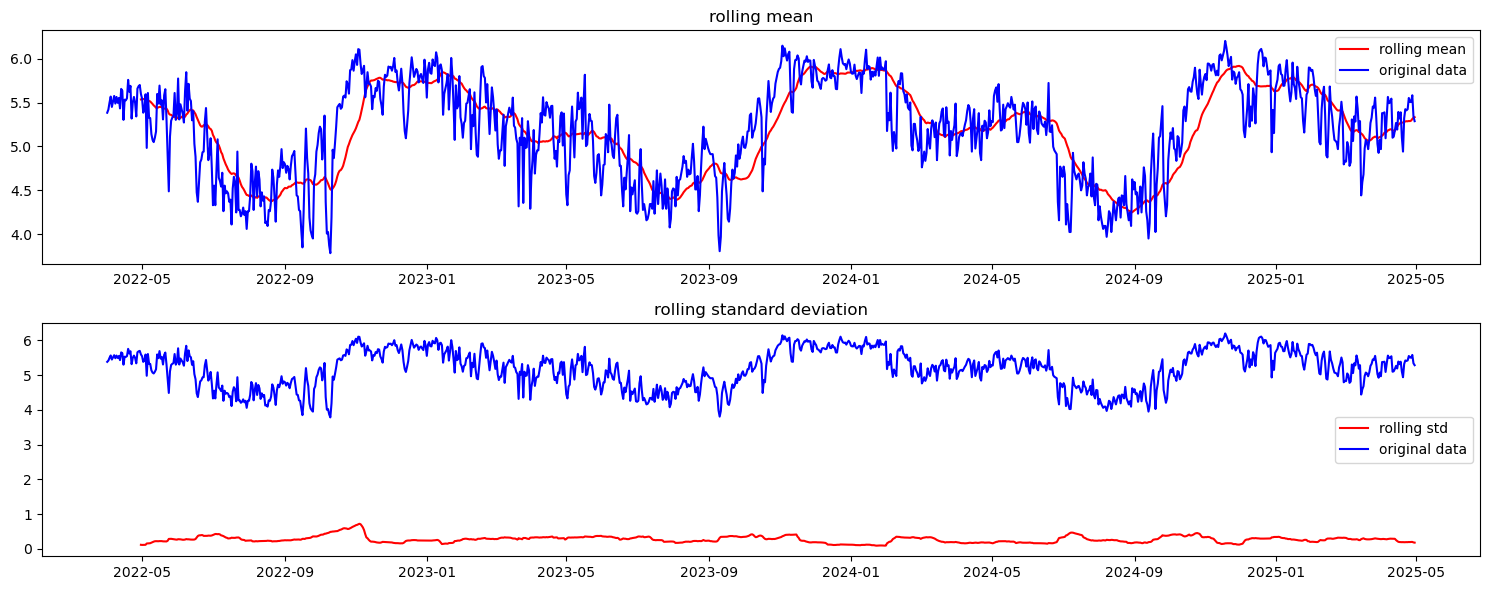

In [13]:
test_stationary(log_scaled)

## Auto-correlation and Partial Auto-correlation plots

In [14]:
from statsmodels.graphics.tsaplots import plot_acf , plot_pacf 

In [15]:
def plot_acf_pacf(timeseries , lags):
    
    fig1 = plot_acf(timeseries , lags=lags)
    fig2 = plot_pacf(timeseries , lags=lags)

    plt.tight_layout()
    plt.show()

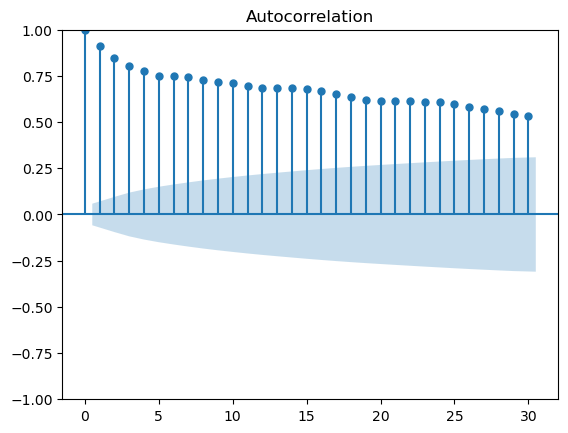

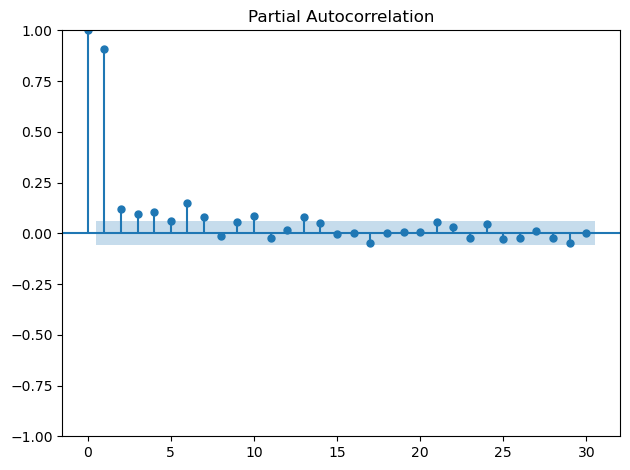

In [16]:
plot_acf_pacf(log_scaled , 30)

## Train Test split

In [17]:
train_size = int(len(df) * 0.8)

train , test = log_scaled[:train_size] , log_scaled[train_size:]

train = train.asfreq('D' ,  method='ffill')
test  = test.asfreq('D' ,  method='ffill')

In [18]:
from pmdarima import auto_arima

In [19]:
model = auto_arima(train,
                   start_p= 0 , start_q= 0,
                   max_p= 4 , max_q=4,
                   d=None , D = None,
                   start_P= 0  , start_Q=0,
                   max_P= 4 , max_Q=4,
                   seasonal=True, m = 30,
                   trace=True , error_action='ignore',
                   stepwise=True , stationary=False
                  )

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[30] intercept   : AIC=-69.915, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[30] intercept   : AIC=-95.995, Time=0.88 sec
 ARIMA(0,1,1)(0,0,1)[30] intercept   : AIC=-108.502, Time=1.10 sec
 ARIMA(0,1,0)(0,0,0)[30]             : AIC=-71.911, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[30] intercept   : AIC=-110.363, Time=0.09 sec
 ARIMA(0,1,1)(1,0,0)[30] intercept   : AIC=-108.509, Time=1.01 sec
 ARIMA(0,1,1)(1,0,1)[30] intercept   : AIC=-106.449, Time=1.27 sec
 ARIMA(1,1,1)(0,0,0)[30] intercept   : AIC=-161.837, Time=0.23 sec
 ARIMA(1,1,1)(1,0,0)[30] intercept   : AIC=-160.157, Time=2.99 sec
 ARIMA(1,1,1)(0,0,1)[30] intercept   : AIC=-160.139, Time=3.30 sec
 ARIMA(1,1,1)(1,0,1)[30] intercept   : AIC=-158.494, Time=5.14 sec
 ARIMA(1,1,0)(0,0,0)[30] intercept   : AIC=-97.943, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[30] intercept   : AIC=-159.863, Time=0.33 sec
 ARIMA(1,1,2)(0,0,0)[30] intercept   : AIC=-159.863, Time=0.39 sec
 ARIMA(0,1,2)(0,0,0)[30

In [20]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.deterministic import DeterministicProcess , CalendarFourier

In [21]:
fourier = CalendarFourier(freq='YE', order=6)

dp = DeterministicProcess(
    index=train.index,
    constant=True,
    order=1,              # trend
    seasonal=False,
    additional_terms=[fourier],
    drop=True,
)

exo = dp.in_sample()

In [22]:
sarima_train = SARIMAX(train ,
                exog=exo,
                 order=model.order , 
                 seasonal_order=(0,0,0,0))

results = sarima_train.fit()

C:\Users\pakas\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Diagonistics

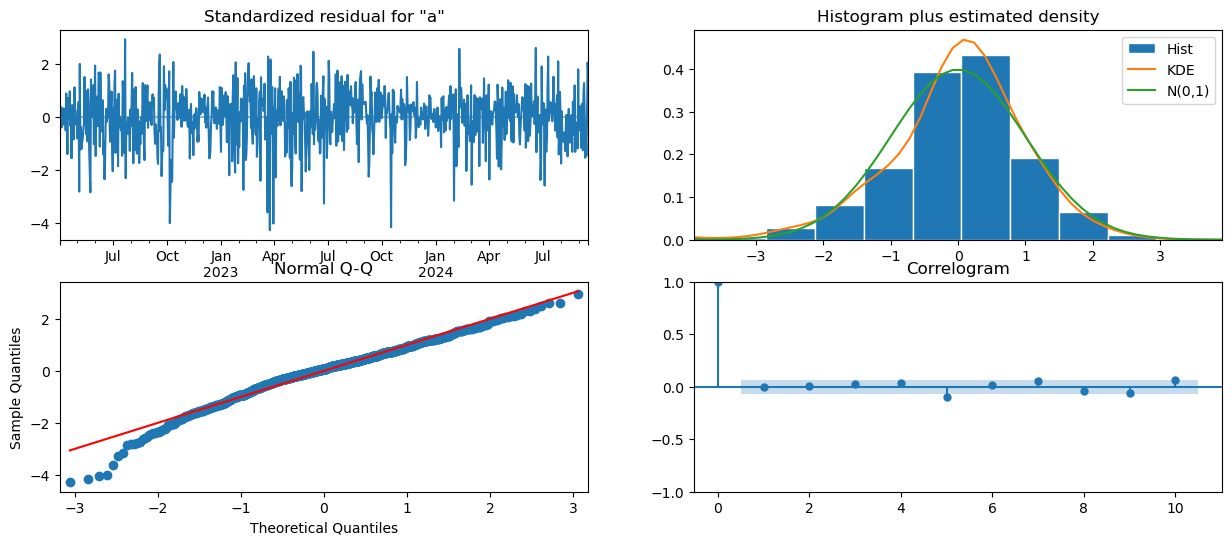

In [23]:
digonistics = results.plot_diagnostics(figsize= figsize)

### Ljung Box results

In [24]:
lb_test = acorr_ljungbox(results.resid , lags=[30] , return_df= True )
lb_test

,lb_stat,lb_pvalue
30,15.595055,0.985917


In [25]:
def plot_forecast(results , train , test):
    exo_future = dp.out_of_sample(steps=len(test))
    
    forecast_obj = results.get_forecast(steps = len(test) , exog = exo_future)
    forecast = forecast_obj.predicted_mean
    conf_int  = forecast_obj.conf_int()

    plt.figure(figsize = figsize)
    
    plt.plot(train , label = 'train')
    plt.plot(test , label = 'test' , color = 'blue')
    plt.plot(forecast , label = 'forecast' , color = 'red')

    plt.fill_between(conf_int.index , 
                     conf_int.iloc[ : ,  0],
                     conf_int.iloc[: , 1],
                    color = 'pink' , alpha  = 0.4)
    
    plt.title("Forecast with Confidence Intervals")
    
    plt.legend(loc = 'best')
    plt.tight_layout()
    plt.show()          

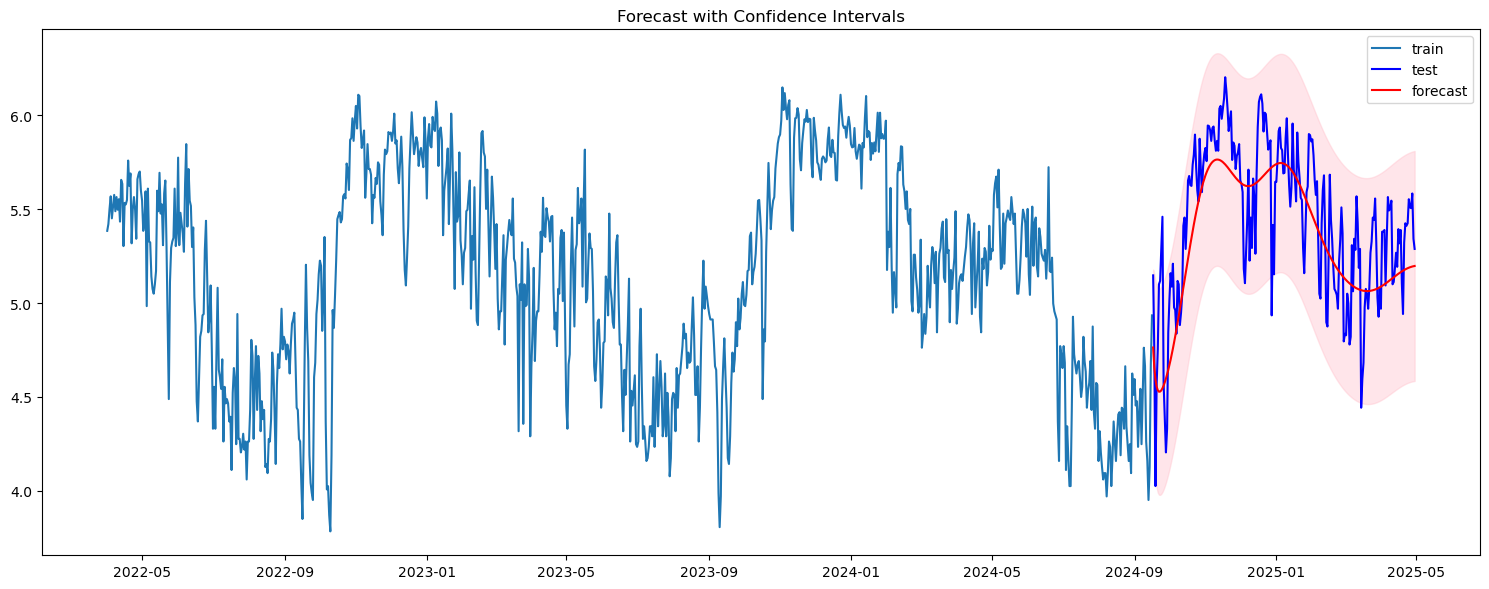

In [26]:
plot_forecast(results , train=train , test=test)

## Evaluation of model

In [27]:
from sklearn.metrics import mean_squared_error

In [28]:
def calcualte_rmse(results , train , test):
    exo_future = dp.out_of_sample(steps=len(test))
    forecast_obj = results.get_forecast(steps = len(test) , exog = exo_future)
    forecast = forecast_obj.predicted_mean

    pr_test = np.exp(forecast.dropna())
    ac_test = np.exp(test.dropna())

    test_rmse = np.sqrt(mean_squared_error(ac_test , pr_test))

    pr_train = np.exp(results.fittedvalues.dropna())
    ac_trian = np.exp(train.loc[pr_train.index])

    train_rmse = np.sqrt(mean_squared_error(ac_trian , pr_train))

    return train_rmse , test_rmse

In [29]:
train_rmse , test_rmse = calcualte_rmse(results=results , train=train , test=test)

print(f"Train RMSE for ARIMA: {train_rmse}")
print(f"Test RMSE for ARIMA: {test_rmse}")

Train RMSE for ARIMA: 38.37793420177888
Test RMSE for ARIMA: 64.38309615723307


## Future forecast

In [30]:
log_scaled = log_scaled.asfreq('D' , method = 'ffill')

final_fourier = CalendarFourier('YE' , order=6)

dp = DeterministicProcess(
    log_scaled.index,
    seasonal=False,
    additional_terms=[final_fourier],
    constant=True,
    order=1,
    drop=True
)

exog = dp.in_sample()

In [31]:
final_model = SARIMAX(log_scaled,
                     order= model.order,
                      exog=exog,
                      seasonal_order=(0,0,0,0)
                     )

final_results = final_model.fit()

C:\Users\pakas\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [32]:
exo_future = dp.out_of_sample(steps = 365) #next year
final_forecast_obj = final_results.get_forecast(steps = 365 , exog = exo_future)
forecast_val = final_forecast_obj.predicted_mean
conf_int  = final_forecast_obj.conf_int()

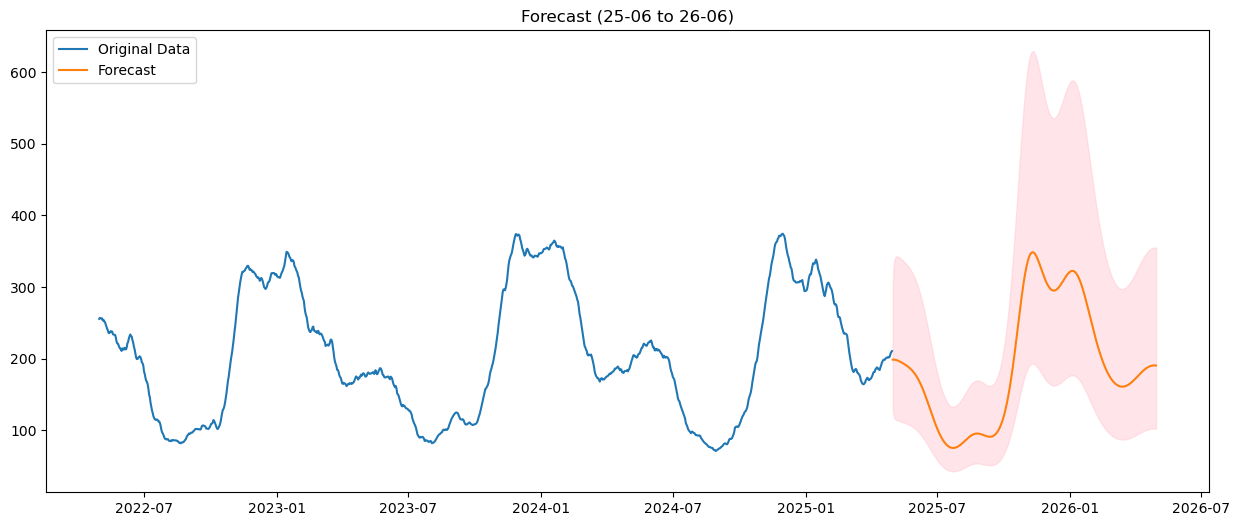

In [33]:
plt.figure(figsize=figsize)

rolling_org  = df.rolling(window = 30).mean()
plt.plot(rolling_org, label='Original Data')
forecast_exp = np.exp(forecast_val)
plt.plot(forecast_exp, label='Forecast')

lower_ci = np.exp(conf_int.iloc[ : , 0 ]).values
upper_ci = np.exp(conf_int.iloc[ : , 1 ]).values

plt.fill_between(conf_int.index,
                 lower_ci,
                 upper_ci,
                 color='pink', alpha=0.4)

plt.title('Forecast (25-06 to 26-06)')
plt.legend()
plt.show()

## Model saving

In [34]:
import pickle

In [35]:
with open("sarimax_model.pkl", "wb") as f:
    pickle.dump(final_results, f)

In [36]:
with open("train_index.pkl", "wb") as f:
    pickle.dump(log_scaled.index, f)

## Model2 - XGBoost

In [74]:
req_data = data[data['state'] == city].drop(columns = ['air_quality_status'])

dfXG = req_data[['date' , 'aqi_value' ]].copy()

In [75]:
dfXG['date'] = pd.to_datetime(dfXG['date'] , format='%d-%m-%Y')
dfXG.sort_values(by = 'date')

,date,aqi_value
235673,2022-04-01,218
235594,2022-04-02,226
235409,2022-04-03,245
235193,2022-04-04,262
235033,2022-04-05,233
...,...,...
933,2025-04-26,247
810,2025-04-27,246
461,2025-04-28,266
355,2025-04-29,209


In [76]:
# Adding features for xgboost

dfXG['AQI_lag1'] = dfXG['aqi_value'].shift(1)
dfXG['AQI_lag7'] = dfXG['aqi_value'].shift(7)
dfXG['AQI_lag30'] = dfXG['aqi_value'].shift(30)

dfXG['dayofweek'] = dfXG['date'].dt.dayofweek
dfXG['month'] = dfXG['date'].dt.month
dfXG['day'] = dfXG['date'].dt.day

dfXG['rolling_mean'] = dfXG['aqi_value'].rolling(window=7).mean()
dfXG['rolling_Std'] = dfXG['aqi_value'].rolling(window=7).std()

In [77]:
# dropping nan values
dfXG.drop(columns=['date'] , inplace = True)
dfXG.dropna(inplace=True)

In [78]:
dfXG = dfXG.reset_index(drop=True)

In [103]:
dfXG['trend'] = range(len(dfXG))

In [80]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split , cross_val_score , GridSearchCV , TimeSeriesSplit
from sklearn.metrics import r2_score

In [81]:
train_size = int(len(dfXG) * 0.8)

train = dfXG[:train_size]
test = dfXG[train_size:]

X_train = train.drop(columns = ['aqi_value'])
y_train= train['aqi_value']

X_test = test.drop(columns = ['aqi_value'])
y_test = test['aqi_value']

In [82]:
xg_params = {
    'n_estimators' : [100 , 200 , 300],
    'max_depth' : [ 3 , 5],
    'subsample': [0.6, 0.8, 1.0],
    'learning_rate' : [0.001 , 0.01],
    'reg_alpha': [0, 1],
    'reg_lambda': [1, 2]
}

In [83]:
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=xg_params,
    cv= tscv,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)


grid.fit(X_train , y_train)
best_model = grid.best_estimator_
best_params = grid.best_params_

In [84]:
print(grid.best_params_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 1, 'reg_lambda': 1, 'subsample': 1.0}


In [85]:
y_pred = best_model.predict(X_test)

print(f'Root mean squared error:  {np.sqrt(mean_squared_error(y_test , y_pred))}')
print(f'R2 score :  {r2_score(y_test , y_pred)}')

Root mean squared error:  37.75345176427167
R2 score :  0.8269191980361938


In [86]:
y_train_pred = best_model.predict(X_train)

train_rmse = np.sqrt(mean_squared_error(y_train ,y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test , y_pred))

print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")

Train RMSE: 35.25805398903561
Test RMSE: 37.75345176427167


## Final XGBoost model

In [87]:
X = dfXG.drop(columns = ['aqi_value'])
y = dfXG['aqi_value']

In [89]:
final_xgb = XGBRegressor(**grid.best_params_)
final_xgb.fit(X , y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [90]:
final_y_pred = final_xgb.predict(X)

print(f'Root mean squared error:  {round(np.sqrt(mean_squared_error(y , final_y_pred)) , 2)}')
print(f'R2 score : {round(r2_score(y , final_y_pred) , 2)}')

Root mean squared error:  35.13
R2 score : 0.88


## Future forecast

In [108]:
def forecast_future(model , df , steps , features):

    history = df.copy().reset_index(drop=True)
    preds = []

    last_dayofweek = history['dayofweek'].iloc[-1]
    last_day = history['day'].iloc[-1]
    last_trend = history['trend'].iloc[-1]
    last_month = history['month'].iloc[-1]
    
    for i in range(steps):

        last_row = history.iloc[-1:].copy()
        
        pred = model.predict(last_row[features])[0]
        preds.append(pred)

        next_row = last_row.copy()
        next_row['aqi_value'] = pred

        new_dayofweek = (last_dayofweek + 1) % 7
        new_month = last_month  
        new_trend = last_trend + 1
        new_day = (last_day % 31) + 1

        next_row['dayofweek'] = new_dayofweek
        next_row['day'] = new_day
        next_row['month'] = new_month
        next_row['trend'] = new_trend

        # lag feature update

        history = pd.concat([history , next_row] ,  ignore_index=True)

        history['AQI_lag1'] =  history['aqi_value'].shift(1)
        history['AQI_lag7'] = history['aqi_value'].shift(7)
        history['AQI_lag30'] = history['aqi_value'].shift(30)

        # update rolling features

        history['rolling_mean'] = history['aqi_value'].rolling(window = 7).mean()
        history['rolling_std'] = history['aqi_value'].rolling(window = 7).std()

        last_dayofweek = new_dayofweek
        last_month = new_month
        last_day = new_day
        last_trend = new_trend

    
    return preds

In [127]:
forecasted_val = forecast_future(model= final_xgb , df = X  , steps=7 , features=X.columns)

In [128]:
i = 1
for val in forecasted_val:
    print(f'Day {i} : {round(val)}')
    i+=1

Day 1 : 245
Day 2 : 386
Day 3 : 291
Day 4 : 360
Day 5 : 299
Day 6 : 341
Day 7 : 314
